## Urban Sound 8K: Clasificación de Sonidos Urbanos con Transformers

### Dataset
El **Urban Sound 8K** es un conjunto de datos con **8,732 clips de audio** de sonidos urbanos reales, capturados en 10 ciudades diferentes. Cada clip dura entre 4-30 segundos y es etiquetado con una de 10 clases de sonido común:

1. **Air Conditioner** - Aire acondicionado
2. **Car Horn** - Bocina de auto
3. **Children Playing** - Niños jugando
4. **Dog Bark** - Ladrido de perro
5. **Drilling** - Taladro/perforación
6. **Engine Idling** - Motor en ralentí
7. **Gun Shot** - Disparo de arma
8. **Jackhammer** - Martillo neumático
9. **Siren** - Sirena (ambulancia/policía)
10. **Street Music** - Música callejera

Fuente: [Zenodo - Urban Sound 8K](https://zenodo.org/records/1203745)

### Objetivo
Entrenar un **Transformer Encoder** para **clasificar automáticamente** estos sonidos urbanos en tiempo real. Este modelo es útil para:
- **Monitoreo ambiental** - detectar eventos ruidosos anormales
- **Vigilancia acústica** - alertas automáticas por sirenas o disparos
- **Aplicaciones inteligentes** - asistentes de voz contextuales basados en sonido ambiental

En lugar de usar redes convolucionales como CNNs, aprovechamos el **mecanismo de atención** para entender relaciones temporales en características MFCC (espectro mel-cepstral).

# *Transformer* Encoder

En posts anteriores hemos entrado en detalle en los mecanismos de atención utilizados en la arquitectura *Transformer*. En este post vamos a implementar nuestro primer *Transformer* completo, en este caso el conocido como *Transformer Encoder*. Esta arquitectura es utilizada en modelos como [BERT](https://arxiv.org/abs/1810.04805) o [ViT](https://arxiv.org/abs/2010.11929).

![](https://github.com/juansensio/blog/blob/master/063_transformer_encoder/encoder.png?raw=1)

Como puedes ver en la figura, un *Transformer* no es más que una secuencia de capas formada por:

- El mecanismo de atención *multi-head* que hemos visto en el post anterior
- Normalización y conexión residual (inspirado en ResNet)
- Un MLP
- Otra normalización y conexión residual

Además, a la entrada de la primera capa, tenemos una etapa de `embedding` para proyectar nuestros *inputs* a la dimensión adecuada a la cual añadimos un `postitional encoding`, el mecanismo que le dirá al transformer en qué posición de la secuencia se encuentra cada vector. Vamos a ver un ejemplo de implementación.

## Implementación

In [1]:
import pytorch_lightning as pl
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader
import librosa
import librosa.display
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
class UrbanSoundDataset(torch.utils.data.Dataset):
    def __init__(self, metadata_path, audio_dir, n_mfcc=13, sr=22050, max_time_steps=200):
        self.metadata = pd.read_csv(metadata_path)
        self.audio_dir = Path(audio_dir)
        self.n_mfcc = n_mfcc
        self.sr = sr
        self.max_time_steps = max_time_steps
        
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        fold = f"fold{row['fold']}"
        file_path = self.audio_dir / fold / row['slice_file_name']
        
        try:
            y, sr = librosa.load(file_path, sr=self.sr)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=self.n_mfcc)
            # Transponer para que sea (tiempo, características)
            mfcc = mfcc.T  # Ahora (tiempo, n_mfcc)
            # Normalizar por feature (z-score por cada coeficiente)
            mfcc = (mfcc - mfcc.mean(axis=0, keepdims=True)) / (mfcc.std(axis=0, keepdims=True) + 1e-8)
            
            # Pad o truncate a longitud fija
            if mfcc.shape[0] < self.max_time_steps:
                padding = np.zeros((self.max_time_steps - mfcc.shape[0], self.n_mfcc))
                mfcc = np.vstack([mfcc, padding])
            else:
                mfcc = mfcc[:self.max_time_steps, :]
            
            mfcc = torch.tensor(mfcc).float()
            label = torch.tensor(row['classID']).long()
            return mfcc, label
        except:
            return torch.zeros(self.max_time_steps, self.n_mfcc).float(), torch.tensor(0).long()

class UrbanSoundDataModule(pl.LightningDataModule):
    def __init__(self, metadata_path, audio_dir, batch_size=32, test_fold=5):
        super().__init__()
        self.metadata_path = metadata_path
        self.audio_dir = audio_dir
        self.batch_size = batch_size
        self.test_fold = test_fold
        
    def setup(self, stage=None):
        full_dataset = UrbanSoundDataset(self.metadata_path, self.audio_dir)
        metadata = pd.read_csv(self.metadata_path)
        
        train_idx = metadata[metadata['fold'] != self.test_fold].index
        test_idx = metadata[metadata['fold'] == self.test_fold].index
        
        self.train_ds = torch.utils.data.Subset(full_dataset, train_idx)
        self.val_ds = torch.utils.data.Subset(full_dataset, test_idx)
    
    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=0)
    
    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, num_workers=0)

In [3]:
metadata_path = r'UrbanSound8K/metadata/UrbanSound8K.csv'
audio_dir = r'UrbanSound8K/audio'

dm = UrbanSoundDataModule(metadata_path, audio_dir, batch_size=96)
dm.setup()
imgs, labels = next(iter(dm.train_dataloader()))
print(f"Batch shape: {imgs.shape}, Labels shape: {labels.shape}")

Batch shape: torch.Size([96, 200, 13]), Labels shape: torch.Size([96])


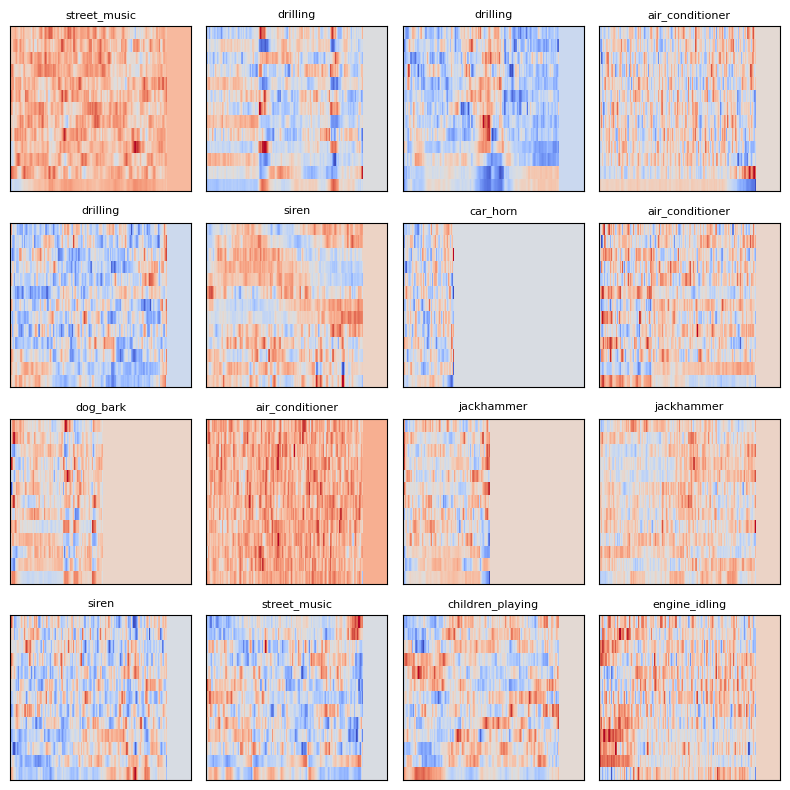

In [4]:
class_names = ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling',
               'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']

r, c = 4, 4
fig = plt.figure(figsize=(2*c, 2*r))
for _r in range(r):
    for _c in range(c):
        ix = _r*c + _c
        ax = plt.subplot(r, c, ix + 1)
        mfcc, label = imgs[ix], labels[ix]
        librosa.display.specshow(mfcc.numpy().T, sr=22050, hop_length=512, ax=ax, x_axis=None, y_axis=None)
        ax.set_title(class_names[label.item()], fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
# basado en: https://github.com/karpathy/minGPT/blob/master/mingpt/model.py
import math

class MultiHeadAttention(torch.nn.Module):

    def __init__(self, n_embd, n_heads):
        super().__init__()
        self.n_heads = n_heads

        # key, query, value projections
        self.key = torch.nn.Linear(n_embd, n_embd*n_heads)
        self.query = torch.nn.Linear(n_embd, n_embd*n_heads)
        self.value = torch.nn.Linear(n_embd, n_embd*n_heads)

        # output projection
        self.proj = torch.nn.Linear(n_embd*n_heads, n_embd)

    def forward(self, x):
        B, L, F = x.size()

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        k = self.key(x).view(B, L, F, self.n_heads).transpose(1, 3) # (B, nh, L, F)
        q = self.query(x).view(B, L, F, self.n_heads).transpose(1, 3) # (B, nh, L, F)
        v = self.value(x).view(B, L, F, self.n_heads).transpose(1, 3) # (B, nh, L, F)

        # attention (B, nh, L, F) x (B, nh, F, L) -> (B, nh, L, L)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = torch.nn.functional.softmax(att, dim=-1)
        y = att @ v # (B, nh, L, L) x (B, nh, L, F) -> (B, nh, L, F)
        y = y.transpose(1, 2).contiguous().view(B, L, F*self.n_heads) # re-assemble all head outputs side by side

        return self.proj(y)

class TransformerBlock(torch.nn.Module):
    def __init__(self, n_embd, n_heads, dropout=0.1):
        super().__init__()
        self.ln1 = torch.nn.LayerNorm(n_embd)
        self.ln2 = torch.nn.LayerNorm(n_embd)
        self.attn = MultiHeadAttention(n_embd, n_heads)
        self.dropout1 = torch.nn.Dropout(dropout)
        self.dropout2 = torch.nn.Dropout(dropout)
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(n_embd, 4 * n_embd),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(4 * n_embd, n_embd),
        )

    def forward(self, x):
        x = self.ln1(x + self.dropout1(self.attn(x)))
        x = self.ln2(x + self.dropout2(self.mlp(x)))
        return x

class UrbanSoundModel(pl.LightningModule):

    def __init__(self, n_input=13, n_embd=64, seq_len=100, n_heads=8, n_layers=3, dropout=0.3, weight_decay=1e-3):
        super().__init__()
        self.seq_len = seq_len
        self.n_embd = n_embd
        self.weight_decay = weight_decay
        
        # Embedding
        self.inp_emb = torch.nn.Linear(n_input, n_embd)
        self.pos_emb = torch.nn.Parameter(torch.zeros(1, seq_len, n_embd))
        self.dropout = torch.nn.Dropout(dropout)
        
        # Transformer blocks - con mejor regularización
        self.transformer = torch.nn.Sequential(*[TransformerBlock(n_embd, n_heads, dropout=dropout) for _ in range(n_layers)])
        
        # Classifier con batchnorm para estabilidad
        self.fc = torch.nn.Sequential(
            torch.nn.LayerNorm(n_embd),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(n_embd, 10)  # 10 clases
        )

    def forward(self, x):
        B = x.size(0)
        # Pad o truncate a seq_len
        if x.size(1) < self.seq_len:
            pad_len = self.seq_len - x.size(1)
            x = torch.nn.functional.pad(x, (0, 0, 0, pad_len))
        else:
            x = x[:, :self.seq_len, :]
        
        # Embedding + positional encoding
        e = self.inp_emb(x) + self.pos_emb
        e = self.dropout(e)
        
        # Transformer
        x = self.transformer(e)
        
        # Clasificación usando mean pooling
        y = self.fc(x.mean(dim=1))
        return y

    def predict(self, x):
        with torch.no_grad():
            y_hat = self(x)
            return torch.argmax(y_hat, axis=1)

    def compute_loss_and_acc(self, batch):
        x, y = batch
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        acc = (torch.argmax(y_hat, axis=1) == y).sum().item() / y.shape[0]
        return loss, acc

    def training_step(self, batch, batch_idx):
        loss, acc = self.compute_loss_and_acc(batch)
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True)
        self.log('train_acc', acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, acc = self.compute_loss_and_acc(batch)
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val_acc', acc, prog_bar=True, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.0004, weight_decay=self.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-6)
        return [optimizer], [{"scheduler": scheduler, "interval": "epoch"}]

Nuestro *Transformer* Encoder procesa características MFCC de archivos de audio urbano y es capaz de clasificar los diferentes tipos de sonido con precisión. El mecanismo de atención permite que el modelo entienda las relaciones temporales en las características de audio.

In [6]:
model = UrbanSoundModel(n_input=13, n_embd=64, seq_len=128, n_heads=4, n_layers=2, dropout=0.1)
output = model(torch.randn(4, 128, 13))
print(f"Output shape: {output.shape}, Parámetros: {sum(p.numel() for p in model.parameters()):,}")

Output shape: torch.Size([4, 10]), Parámetros: 209,290


In [7]:
model = UrbanSoundModel(n_input=13, n_embd=96, seq_len=128, n_heads=5, n_layers=3, dropout=0.35, weight_decay=3e-3)

from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

early_stop_callback = EarlyStopping(monitor='val_loss', patience=12, verbose=True, mode='min', check_on_train_epoch_end=False)

checkpoint_callback = ModelCheckpoint(monitor='val_acc', dirpath='checkpoints', filename='best-checkpoint-{epoch:02d}', save_top_k=1, mode='max')

trainer = pl.Trainer(max_epochs=15, enable_progress_bar=True,callbacks=[early_stop_callback, checkpoint_callback],log_every_n_steps=1,check_val_every_n_epoch=1,precision='16-mixed',
    num_sanity_val_steps=0, logger=True,  enable_checkpointing=True)

trainer.fit(model, dm)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 6GB Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ inp_emb      │ Linear     │  1.3 K │ train │     0 │
│ 1 │ dropout      │ Dropout    │      0 │ train │     0 │
│ 2 │ transformer  │ Sequential │  781 K │ train │     0 │
│ 3 │ fc           │ Sequential │  1.2 K │ train │     0 │
│   │ other params │ n/a        │ 12.3 K │ n/a   │   n/a │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 796 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 796 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 52                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_loss improved. New best score: 2.026
Metric val_loss improved by 0.165 >= min_delta = 0.0. New best score: 1.861
Metric val_loss improved by 0.072 >= min_delta = 0.0. New best score: 1.789
Metric val_loss improved by 0.105 >= min_delta = 0.0. New best score: 1.685
Metric val_loss improved by 0.020 >= min_delta = 0.0. New best score: 1.664
`Trainer.fit` stopped: `max_epochs=15` reached.


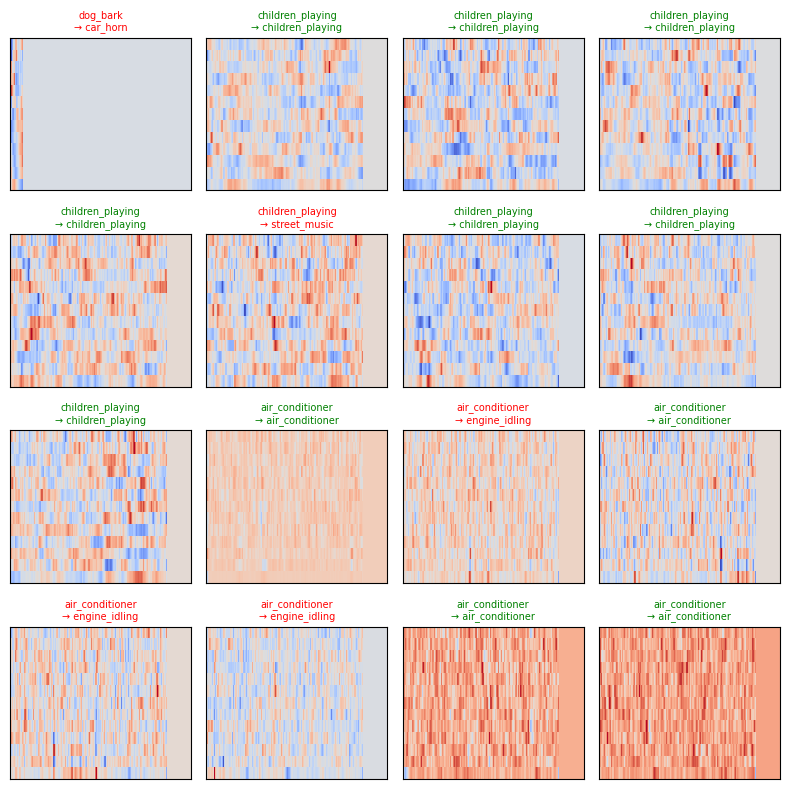

In [8]:
try:
    imgs, labels = next(iter(dm.val_dataloader()))
    preds = model.predict(imgs)

    r, c = 4, 4
    fig = plt.figure(figsize=(2*c, 2*r))
    for _r in range(r):
        for _c in range(c):
            ix = _r*c + _c
            if ix < len(imgs):
                ax = plt.subplot(r, c, ix + 1)
                mfcc, label = imgs[ix], labels[ix]
                librosa.display.specshow(mfcc.numpy().T, sr=22050, hop_length=512, ax=ax, x_axis=None, y_axis=None)
                true_label = class_names[label.item()]
                pred_label = class_names[preds[ix].item()]
                color = "green" if label == preds[ix] else "red"
                ax.set_title(f'{true_label}\n→ {pred_label}', fontsize=7, color=color)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error en visualización: {e}")

Ahora vamos a resolver el mismo problema de clasificación, utilizando un *Transformer* Encoder. En lugar de trabajar con imágenes divididas en patches, usamos características de audio extraídas de los archivos de audio del dataset Urban Sound 8K. Extraemos características MFCC (Mel Frequency Cepstral Coefficients) que el mecanismo de atención puede procesar como una secuencia temporal.

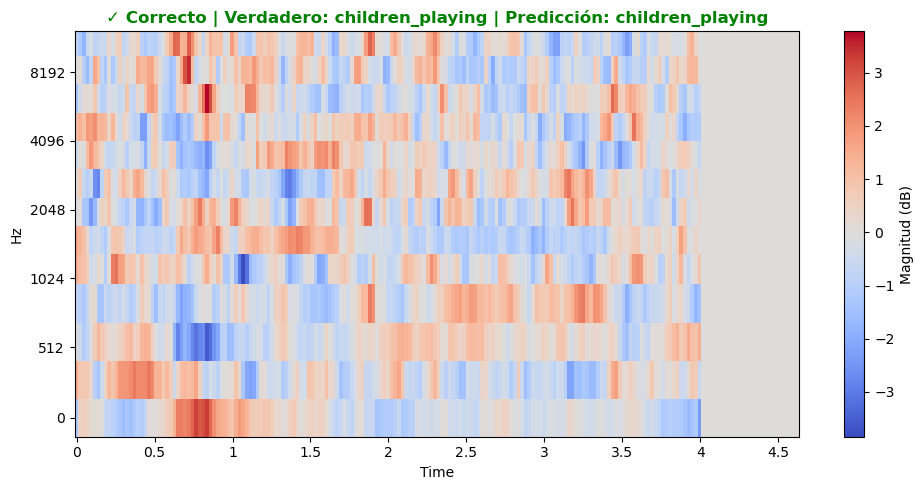

Predicción: children_playing | Real: children_playing | Correcto ✓


In [9]:
import random

try:
    val_batch = next(iter(dm.val_dataloader()))
    attn_imgs, attn_labels = val_batch
    preds = model.predict(attn_imgs)
    
    ix = random.randint(0, min(7, attn_imgs.size(0)-1))
    fig = plt.figure(figsize=(10, 5))
    
    ax = plt.subplot(1, 1, 1)
    mfcc = attn_imgs[ix].numpy()
    im = librosa.display.specshow(mfcc.T, sr=22050, hop_length=512, ax=ax, x_axis='time', y_axis='mel')
    true_label = class_names[attn_labels[ix].item()]
    pred_label = class_names[preds[ix].item()]
    is_correct = attn_labels[ix] == preds[ix].item()
    color = "green" if is_correct else "red"
    status = "✓ Correcto" if is_correct else "✗ Incorrecto"
    ax.set_title(f'{status} | Verdadero: {true_label} | Predicción: {pred_label}', color=color, fontsize=12, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax, label='Magnitud (dB)')
    plt.tight_layout()
    plt.show()
    print(f"Predicción: {pred_label} | Real: {true_label} | {'Correcto ✓' if is_correct else 'Incorrecto ✗'}")
except Exception as e:
    print(f"Error en visualización: {e}")
    import traceback
    traceback.print_exc()

## Resumen

En este notebook hemos implementado un *Transformer* Encoder para la clasificación de sonidos urbanos usando el dataset Urban Sound 8K 

Extrajimos características MFCC de los archivos de audio y luego las procesamos con mecanismos de atención multi-cabeza. El modelo puede capturar relaciones temporales en las características de audio, permitiendo una clasificación efectiva de diferentes tipos de sonidos urbanos (sirenas, ladridos, etc.). El *Transformer* Encoder demuestra cómo la atención es una herramienta poderosa no solo para lenguaje natural, sino también para datos de audio.